<a href="https://colab.research.google.com/github/Annesya/vcca-tutorial-periphery/blob/main/Model_of_Auditory_Periphery_Zilany.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bruce, Erfani, Zilany (2018) model of auditory periphery

#### Simulation of a more realistic auditory periphery

#### If you find this resources useful, please cite:

#### `Saddler, M.R., Gonzalez, R. and McDermott, J.H., 2021. Deep neural network models reveal interplay of peripheral coding and stimulus statistics in pitch perception. Nature communications, 12(1), p.7278.` (**Repo**: https://github.com/msaddler/bez2018model.git)

#### `Bruce, I.C., Erfani, Y. and Zilany, M.S., 2018. A phenomenological model of the synapse between the inner hair cell and auditory nerve: Implications of limited neurotransmitter release sites. Hearing research, 360, pp.40-54.`

In [1]:
!git clone https://github.com/Annesya/vcca-tutorial-periphery.git
%cd vcca-tutorial-periphery
!ls -l

Cloning into 'vcca-tutorial-periphery'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 44 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 3.45 MiB | 9.40 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/vcca-tutorial-periphery
total 4296
-rw-r--r-- 1 root root   80078 Jun 19 14:35 complex_tone_500hz_harmonics_1_to_10.wav
-rw-r--r-- 1 root root  160058 Jun 19 14:35 example_speech_in_noise.wav
-rw-r--r-- 1 root root    2425 Jun 19 14:35 filters.py
-rw-r--r-- 1 root root    1073 Jun 19 14:35 LICENSE
-rw-r--r-- 1 root root 3676928 Jun 19 14:35 model_of_auditory_periphery_simplified_w_comments.ipynb
-rw-r--r-- 1 root root  254997 Jun 19 14:35 Model_of_Auditory_Periphery_Zilany.ipynb
-rw-r--r-- 1 root root   15530 Jun 19 14:35 modules.py
-rw-r--r-- 1 root root   80078 Jun 19 14:35 pure_tone_2000hz.wav
-rw-r--r-- 1 root root   80078 Jun 19 1

In [2]:
!git clone https://github.com/msaddler/bez2018model.git


Cloning into 'bez2018model'...
remote: Enumerating objects: 611, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 611 (delta 19), reused 37 (delta 19), pack-reused 574 (from 1)
Receiving objects: 100% (611/611), 6.60 MiB | 30.58 MiB/s, done.
Resolving deltas: 100% (309/309), done.


In [5]:
import glob
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import torch
import torchaudio
import tqdm

import os
import sys

import time

import bez2018model

### Set up the modules

In [6]:
# Build the Cython extension for bez2018model
%cd /content/vcca-tutorial-periphery/bez2018model
!python setup.py build_ext --inplace
%cd /content # Change back to the content directory

/content/vcca-tutorial-periphery/bez2018model
Compiling cython_bez2018.pyx because it changed.
[1/1] Cythonizing cython_bez2018.pyx
/usr/local/lib/python3.12/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/vcca-tutorial-periphery/bez2018model/cython_bez2018.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)
In file included from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarraytypes.h:1909,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from cython_bez2018.c:1247:
/usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRE

### Read an example audio file

In [8]:
audio_file_path = '/content/vcca-tutorial-periphery/example_speech_in_noise.wav'
waveform, sample_rate = torchaudio.load(audio_file_path)

print(f"Waveform shape: {waveform.shape}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {waveform.shape[-1] / sample_rate:.2f} seconds")

Waveform shape: torch.Size([1, 40000])
Sample rate: 20000 Hz
Duration: 2.00 seconds


### Define the model parameters and obtain the periphery output

In [9]:
from bez2018model import bez2018model as b_model
kwargs_nervegram = {
    'nervegram_dur': 2, # <-- duration of final nervegram in seconds (<= stimulus duration)
    'nervegram_fs': 20e3, # <-- sampling rate of nervegram in Hz
    'buffer_start_dur': 0.070, # <-- trim first 70ms of the full-length nervegram
    'buffer_end_dur': 0.010, # <-- trim last 10ms of the full-lenght nervegram
    'pin_fs': 100e3,
    'pin_dBSPL_flag': 0,
    'pin_dBSPL': None,
    'species': 2,
    'bandwidth_scale_factor': 1.0, # <-- scale cochlear filter bandwidths
    'cf_list': None,
    'num_cf': 100, # <-- specify 100 freqency channels ERB-spaced between 125 and 14000 Hz
    'min_cf': 125,
    'max_cf': 8e3,
    'max_spikes_per_train': 1000, # <-- maximum number of spikes to store (too low may raise error)
    'num_spike_trains': 20, # <-- number of spike trains to sample per frequency channel
    'cohc': 1.0,
    'cihc': 1.0,
    'IhcLowPass_cutoff': 3000, # <-- adjust upper frequency limit of auditory nerve phase-locking
    'IhcLowPass_order': 7,
    'spont': 70.0,
    'noiseType': 0,
    'implnt': 0,
    'tabs': 6e-4,
    'trel': 6e-4,
    'random_seed': None,
    'return_vihcs': False, # <-- "nervegram_vihcs" contains instantaneous IHC voltages
    'return_meanrates': True, # <-- "nervegram_meanrates" contains instantaneous firing rates
    'return_spike_times': False,
    'return_spike_tensor_sparse': False,
    'return_spike_tensor_dense': True, # <-- "nervegram_spike_tensor_dense" contains individual spikes
    'nervegram_spike_tensor_fs': 10e3, # <-- sampling rate of dense spike tensor in Hz
}

# NOTE: run times will be slow if spikes are requested, especially for large `num_spike_trains`
# (set `return_spike_*` flags to False if instantaneous firing rate estimates are sufficient)

t0 = time.time()
nervegram_output_dict = b_model.nervegram(waveform.squeeze().numpy(), sample_rate, **kwargs_nervegram)
t1 = time.time()
print("Auditory nerve model run time: {:.2f} seconds".format(t1-t0))
print("Auditory nerve model outputs: (key, shape, dtype / value)")
for k in sorted(nervegram_output_dict.keys()):
    if len(np.array(nervegram_output_dict[k]).shape) == 0:
        print('|__', k, np.array(nervegram_output_dict[k]).shape, nervegram_output_dict[k])
    else:
        print('|__', k, np.array(nervegram_output_dict[k]).shape, np.array(nervegram_output_dict[k]).dtype)

/content/vcca-tutorial-periphery/bez2018model/bez2018model.py:186: RuntimeWarning: divide by zero encountered in scalar divide
  synapse_out = cython_bez2018.run_anf(


Auditory nerve model run time: 85.98 seconds
Auditory nerve model outputs: (key, shape, dtype / value)
|__ IhcLowPass_cutoff () 3000
|__ IhcLowPass_order () 7
|__ bandwidth_scale_factor (100,) float32
|__ buffer_end_dur () 0.01
|__ buffer_start_dur () 0.07
|__ cf_list (100,) float32
|__ cihc (100,) float64
|__ cohc (100,) float64
|__ implnt () 0
|__ max_spikes_per_train () 1000
|__ nervegram_dur () 2.0
|__ nervegram_fs () 20000.0
|__ nervegram_meanrates (100, 40000) float32
|__ nervegram_spike_tensor_dense (20, 100, 20000) bool
|__ nervegram_spike_tensor_fs () 10000.0
|__ noiseType () 0
|__ num_spike_trains () 20
|__ pin (200000,) float32
|__ pin_dBSPL () 70.00356031189656
|__ pin_dBSPL_flag () 0
|__ pin_fs () 100000.0
|__ signal (40000,) float32
|__ signal_fs () 20000
|__ species () 2
|__ spont () 70.0
|__ synapseMode () 0
|__ tabs () 0.0006
|__ trel () 0.0006


### Plot the nerve representation

In [12]:
%cd /content/vcca-tutorial-periphery

import utils

/content/vcca-tutorial-periphery


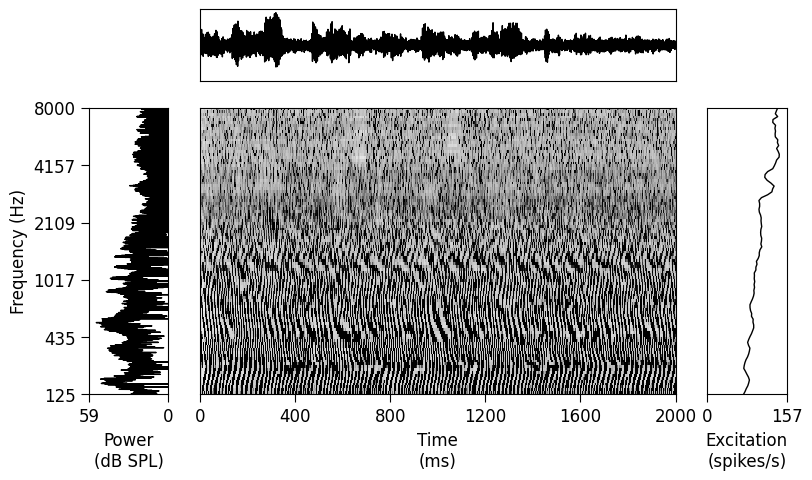

In [13]:
nervegram = nervegram_output_dict['nervegram_meanrates']

# Make sure the original acoustic waveform is 1D so it can be plotted above or
# alongside the nervegram. This helps connect the neural representation back to
# the original sound pressure waveform.
waveform_1d = waveform.numpy().squeeze()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform_1d,
    nervegram=nervegram,
    sr_waveform=nervegram_output_dict['signal_fs'],
    sr_nervegram=nervegram_output_dict['nervegram_fs'],
    cfs=nervegram_output_dict['cf_list'],
)
plt.show()